# Conformity analytics: scores, groupings, preprocessing

Loads the SQLite DB (`events`, `cleaned`, `scores`), summarizes preprocessing coverage, and plots mean FUN / NSI / INSI / ISI scores by event metadata.

**Working directory:** The first code cell adds the repo root to `sys.path`, so you can run with the kernel’s cwd as either the repository root or the `notebooks/` folder. The database path is still `data/raw/events.db` under the repo.

In [13]:
import sys

# resolve the path for convenience
from pathlib import Path
def _repo_root_for_notebook() -> Path:
    """Directory containing `project_config.py` (walk up from cwd so `notebooks/` works)."""
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "project_config.py").is_file():
            return p
    return here

# add the repo root to sys.path
_REPO = _repo_root_for_notebook()
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))

In [14]:
from __future__ import annotations

import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from project_config import DATA_DIR, DB_FILENAME, repo_root

%matplotlib inline

# Judge model id stored in `scores.model_name` (Ollama tag or OpenAI model name).
MODEL_NAME = "gpt-5.4-mini"  # must match scores.model_name (OpenAI: same id as judge --model)

DB_PATH: Path = repo_root() / DATA_DIR / DB_FILENAME
RANDOM_SEED = 42
CLEAN_SAMPLE_N = 12
ACTOR_TOP_N = 15
ACTOR_MIN_N = 5

SCORE_COLS = ["fun_score", "nsi_score", "insi_score", "isi_score"]

print("DB:", DB_PATH.resolve())
print("MODEL_NAME:", MODEL_NAME)
print("DB exists:", DB_PATH.is_file())

DB: /Users/naataaniitsosie/repos/swe-principals/data/raw/events.db
MODEL_NAME: gpt-5.4-mini
DB exists: True


## Available judge models

If the main query returns no rows, pick a `model_name` from this list.

In [15]:
def connect() -> sqlite3.Connection:
    return sqlite3.connect(str(DB_PATH))


with connect() as conn:
    models = pd.read_sql("SELECT model_name, COUNT(*) AS n FROM scores GROUP BY model_name ORDER BY n DESC", conn)
models

,model_name,n
0,gpt-5.4-mini,100


## Load analysis frame (cleaned + events + scores)

`author_association` uses the same fallback order as `preprocessing.workflow._get_author_association` (comment → review → pull_request → issue).

In [18]:
SQL_ANALYSIS = """
SELECT
  c.id AS comment_id,
  c.cleaned_text,
  json_extract(e.event_data, '$.type') AS event_type,
  json_extract(e.event_data, '$.repo.name') AS repo,
  json_extract(e.event_data, '$.created_at') AS created_at,
  date(json_extract(e.event_data, '$.created_at')) AS event_date,
  COALESCE(
    json_extract(e.event_data, '$.actor.login'),
    json_extract(e.event_data, '$.actor.display_login'),
    ''
  ) AS actor_login,
  COALESCE(
    json_extract(e.event_data, '$.payload.comment.author_association'),
    json_extract(e.event_data, '$.payload.review.author_association'),
    json_extract(e.event_data, '$.payload.pull_request.author_association'),
    json_extract(e.event_data, '$.payload.issue.author_association'),
    ''
  ) AS author_association,
  s.fun_score,
  s.nsi_score,
  s.insi_score,
  s.isi_score,
  s.model_name
FROM cleaned c
INNER JOIN events e ON e.id = c.id
INNER JOIN scores s ON s.comment_id = c.id
WHERE s.model_name = ?
"""

with connect() as conn:
    df = pd.read_sql(SQL_ANALYSIS, conn, params=[MODEL_NAME])

for col in SCORE_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
df["actor_login"] = df["actor_login"].fillna("").astype(str)
df["author_association"] = df["author_association"].fillna("").astype(str)
df["event_type"] = df["event_type"].fillna("").astype(str)
df["repo"] = df["repo"].fillna("").astype(str)

len(df), df.head(3)

(100,
     comment_id      cleaned_text        event_type               repo  \
 0  34517387521  update readme.md  PullRequestEvent  expressjs/express   
 1  34548195471  update readme.md  PullRequestEvent  expressjs/express   
 2  34548363302  update readme.md  PullRequestEvent  expressjs/express   
 
              created_at event_date    actor_login author_association  \
 0  2024-01-02T12:39:37Z 2024-01-02   UlisesGascon               NONE   
 1  2024-01-03T15:59:56Z 2024-01-03  Usmanbutt6636               NONE   
 2  2024-01-03T16:06:01Z 2024-01-03   UlisesGascon               NONE   
 
    fun_score  nsi_score  insi_score  isi_score    model_name  
 0          0          0           0          0  gpt-5.4-mini  
 1          0          0           0          0  gpt-5.4-mini  
 2          0          0           0          0  gpt-5.4-mini  )

## Preprocessing and coverage

- **`events`**: every raw GitHub event ingested by `dataset.py`.
- **`cleaned`**: rows that survived `preprocess.py` (text extraction, bot filter, stripping, token count ≥ 2). The current `default_workflow()` in `preprocessing/workflow.py` has **`filter_trivial` commented out**, so trivial comments are not dropped by that step.
- **`scores`**: LLM judge output for a subset of cleaned comments.

The metrics table below uses **`count`** (integer row counts) and **`percent`** (coverage as 0–100, two decimal places; not applicable for pure count rows).

**Limitation:** Per-step drop counts (bots, missing text, too few tokens, duplicate event ids, etc.) are **not stored in SQLite**. Only aggregate `read / duplicates / kept` appears in logs when you run `preprocess.py`. A full funnel breakdown needs instrumented preprocessing or saved logs—not derivable from the DB alone beyond overall `|events|` vs `|cleaned|`.

In [20]:
SQL_CLEANED_SAMPLE = """
SELECT
  c.id AS comment_id,
  json_extract(e.event_data, '$.type') AS event_type,
  json_extract(e.event_data, '$.repo.name') AS repo,
  date(json_extract(e.event_data, '$.created_at')) AS event_date,
  COALESCE(
    json_extract(e.event_data, '$.actor.login'),
    json_extract(e.event_data, '$.actor.display_login'),
    ''
  ) AS actor_login,
  substr(c.cleaned_text, 1, 200) AS cleaned_text_preview
FROM cleaned c
INNER JOIN events e ON e.id = c.id
"""

with connect() as conn:
    n_events = int(pd.read_sql("SELECT COUNT(*) AS n FROM events", conn)["n"].iloc[0])
    n_cleaned = int(pd.read_sql("SELECT COUNT(*) AS n FROM cleaned", conn)["n"].iloc[0])
    n_scores_total = int(pd.read_sql("SELECT COUNT(*) AS n FROM scores", conn)["n"].iloc[0])
    n_scored_model = int(
        pd.read_sql(
            "SELECT COUNT(*) AS n FROM scores WHERE model_name = ?",
            conn,
            params=[MODEL_NAME],
        )["n"].iloc[0]
    )
    n_scored_distinct = int(
        pd.read_sql(
            "SELECT COUNT(DISTINCT comment_id) AS n FROM scores WHERE model_name = ?",
            conn,
            params=[MODEL_NAME],
        )["n"].iloc[0]
    )
    cleaned_sample = pd.read_sql(SQL_CLEANED_SAMPLE, conn)

pct_cleaned_vs_events = round(100.0 * n_cleaned / n_events, 2) if n_events else float("nan")
pct_scored_vs_cleaned = round(100.0 * n_scored_distinct / n_cleaned, 2) if n_cleaned else float("nan")

preprocess_metrics = pd.DataFrame(
    [
        {"metric": "events (raw rows)", "count": n_events, "percent": pd.NA},
        {"metric": "cleaned (after preprocess)", "count": n_cleaned, "percent": pd.NA},
        {"metric": f"scores rows (model={MODEL_NAME})", "count": n_scored_model, "percent": pd.NA},
        {"metric": f"distinct scored comments (model={MODEL_NAME})", "count": n_scored_distinct, "percent": pd.NA},
        {"metric": "scores rows (all models)", "count": n_scores_total, "percent": pd.NA},
        {"metric": "coverage cleaned / events (%)", "count": pd.NA, "percent": pct_cleaned_vs_events},
        {"metric": "coverage scored / cleaned, distinct (%)", "count": pd.NA, "percent": pct_scored_vs_cleaned},
    ]
)
preprocess_metrics["count"] = preprocess_metrics["count"].astype("Int64")
preprocess_metrics["percent"] = preprocess_metrics["percent"].astype("Float64")
preprocess_metrics

,metric,count,percent
0,events (raw rows),41936,<NA>
1,cleaned (after preprocess),37197,<NA>
2,scores rows (model=gpt-5.4-mini),100,<NA>
3,distinct scored comments (model=gpt-5.4-mini),100,<NA>
4,scores rows (all models),100,<NA>
5,coverage cleaned / events (%),<NA>,88.7
6,"coverage scored / cleaned, distinct (%)",<NA>,0.27


In [21]:
sample_cleaned = cleaned_sample.sample(
    n=min(CLEAN_SAMPLE_N, len(cleaned_sample)),
    random_state=RANDOM_SEED,
).sort_values(["repo", "event_date"])
sample_cleaned

,comment_id,event_type,repo,event_date,actor_login,cleaned_text_preview
70,34557567965,PullRequestReviewCommentEvent,django/django,2024-01-03,saippuakauppias,`exception` here is: ```python tests = [ broke...
8943,42319990559,PullRequestEvent,django/django,2024-09-27,saJaeHyukc,refs #35734 -- updated postgresql version in s...
33311,43898116171,PullRequestEvent,django/django,2024-11-17,Inzamamulhaq01,update shell.py auto import models #### trac t...
36476,44875693863,IssueCommentEvent,expressjs/express,2024-12-17,axhuwastaken,could you share more context about your projec...
21879,36094303605,PullRequestEvent,spring-projects/spring-boot,2024-02-28,philwebb,replace string concatenation with stringbuilde...
24288,39492466819,IssueCommentEvent,spring-projects/spring-boot,2024-06-21,mvitz,@philwebb thanks for your quick reply. anythin...
25951,41735962967,IssueCommentEvent,spring-projects/spring-boot,2024-09-09,philwebb,i'm not sure why `messagesourceproperties` is ...
31681,43434997196,PullRequestEvent,spring-projects/spring-boot,2024-11-01,philwebb,add date and uuid deserialization support in n...
37049,45105017303,IssueCommentEvent,spring-projects/spring-boot,2024-12-27,pivotal-cla,@taewoocode thank you for signing the [contrib...
29187,35846454429,IssueCommentEvent,tiangolo/fastapi,2024-02-20,nilslindemann,danke sehr!


### Actor “role” in this dataset

- **`author_association`** (above) is GitHub’s label for the author’s relationship to the repo on that object (e.g. `MEMBER`, `OWNER`). It is not org job title.
- Richer roles (maintainer lists, teams) require the GitHub API or an external mapping merged by `login`.

## Mean scores by dimension

Overall means for the selected model (same row set as `df`).

In [22]:
if len(df) == 0:
    print("No rows: check MODEL_NAME against the models table above.")
else:
    display(df[SCORE_COLS].mean().to_frame("mean").T)
    display(df[SCORE_COLS].describe().T)

,fun_score,nsi_score,insi_score,isi_score
mean,0.38,0.06,0.21,0.46


,count,mean,std,min,25%,50%,75%,max
fun_score,100.0,0.38,0.873632,0.0,0.0,0.0,0.0,3.0
nsi_score,100.0,0.06,0.422116,0.0,0.0,0.0,0.0,3.0
insi_score,100.0,0.21,0.537390,0.0,0.0,0.0,0.0,2.0
isi_score,100.0,0.46,0.757721,0.0,0.0,0.0,1.0,3.0


## Grouped means and counts

Helpers: single-column groupbys, two-way tables, and **top-N + Other** for high-cardinality `actor_login`.

In [23]:
def summarize_by(
    data: pd.DataFrame,
    by: list[str] | str,
    min_n: int = 1,
) -> pd.DataFrame:
    cols = [by] if isinstance(by, str) else list(by)
    g = data.groupby(cols, dropna=False)
    out = g[SCORE_COLS].mean()
    out["n"] = g.size()
    out = out.reset_index()
    return out[out["n"] >= min_n].sort_values("n", ascending=False)


def bucket_top_n_series(s: pd.Series, top_n: int, other_label: str = "Other") -> pd.Series:
    counts = s.value_counts()
    keep = set(counts.head(top_n).index)
    return s.where(s.isin(keep), other_label)


def plot_group_means(
    summary: pd.DataFrame,
    label_col: str,
    title: str,
    max_labels: int = 25,
) -> None:
    plot_df = summary.head(max_labels).copy()
    if plot_df.empty:
        print("Nothing to plot.")
        return
    x = range(len(plot_df))
    width = 0.2
    fig, ax = plt.subplots(figsize=(max(8, len(plot_df) * 0.35), 5))
    for i, col in enumerate(SCORE_COLS):
        ax.bar([xi + (i - 1.5) * width for xi in x], plot_df[col], width=width, label=col)
    ax.set_xticks(list(x))
    ax.set_xticklabels(plot_df[label_col], rotation=45, ha="right")
    ax.set_ylabel("Mean score (0–3)")
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 3.2)
    plt.tight_layout()
    plt.show()


def plot_heatmap(
    data: pd.DataFrame,
    row: str,
    col: str,
    value: str,
    title: str,
) -> None:
    if data.empty:
        print("Nothing to plot.")
        return
    pt = data.pivot_table(index=row, columns=col, values=value, aggfunc="mean")
    if pt.empty:
        print("Pivot empty.")
        return
    fig, ax = plt.subplots(figsize=(max(6, pt.shape[1] * 0.6), max(4, pt.shape[0] * 0.45)))
    im = ax.imshow(pt.values, aspect="auto", vmin=0, vmax=3, cmap="viridis")
    ax.set_xticks(range(pt.shape[1]))
    ax.set_xticklabels(pt.columns, rotation=45, ha="right")
    ax.set_yticks(range(pt.shape[0]))
    ax.set_yticklabels(pt.index)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="Mean")
    plt.tight_layout()
    plt.show()

event_type — groups: 4


,event_type,fun_score,nsi_score,insi_score,isi_score,n
1,PullRequestEvent,0.103448,0.000000,0.137931,0.034483,58
0,IssueCommentEvent,0.789474,0.157895,0.342105,1.078947,38
3,PullRequestReviewEvent,0.000000,0.000000,0.000000,0.333333,3
2,PullRequestReviewCommentEvent,2.000000,0.000000,0.000000,2.000000,1


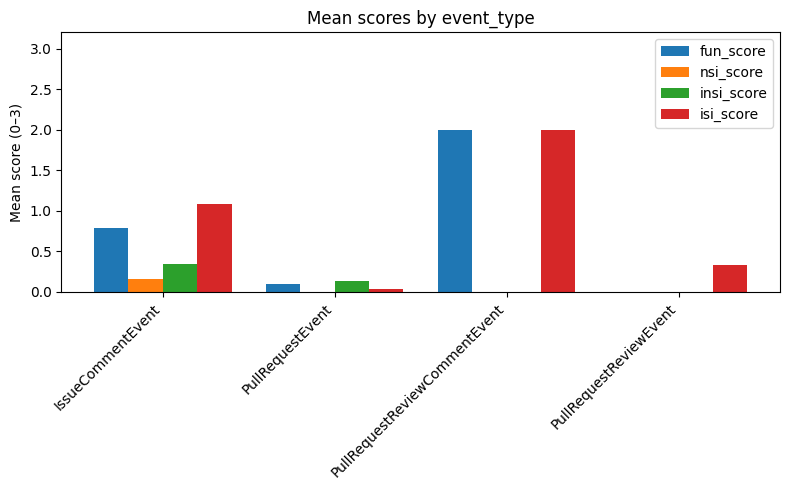

repo — groups: 1


,repo,fun_score,nsi_score,insi_score,isi_score,n
0,expressjs/express,0.38,0.06,0.21,0.46,100


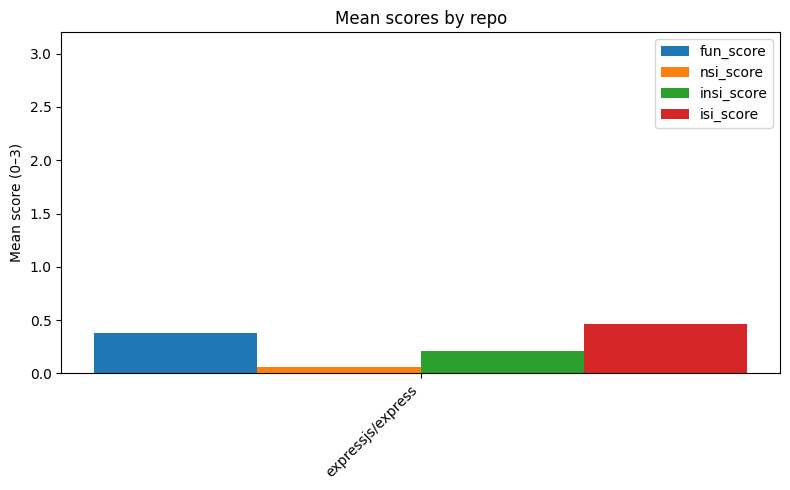

author_association — groups: 2


,author_association,fun_score,nsi_score,insi_score,isi_score,n
1,NONE,0.380435,0.00,0.184783,0.434783,92
0,MEMBER,0.375000,0.75,0.500000,0.750000,8


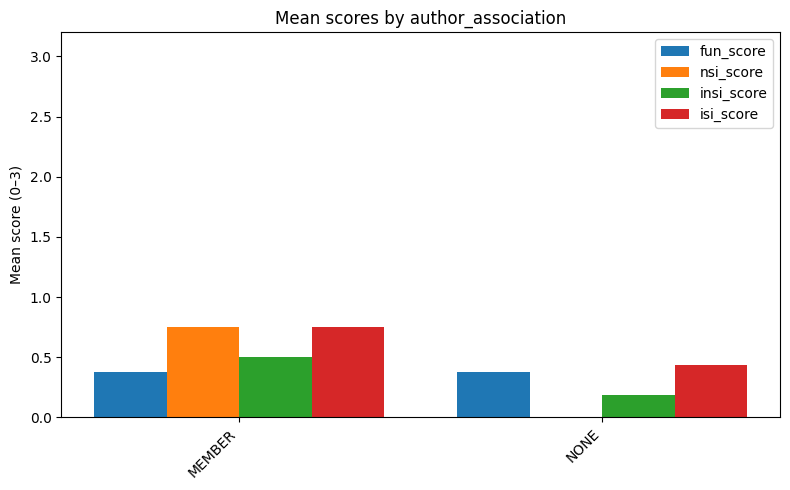

,event_week,fun_score,nsi_score,insi_score,isi_score,n
3,2024-01-22/2024-01-28,0.578947,0.157895,0.263158,0.684211,38
2,2024-01-15/2024-01-21,0.323529,0.000000,0.235294,0.352941,34
0,2024-01-01/2024-01-07,0.117647,0.000000,0.176471,0.294118,17
4,2024-01-29/2024-02-04,0.000000,0.000000,0.000000,0.166667,6
1,2024-01-08/2024-01-14,0.600000,0.000000,0.000000,0.400000,5


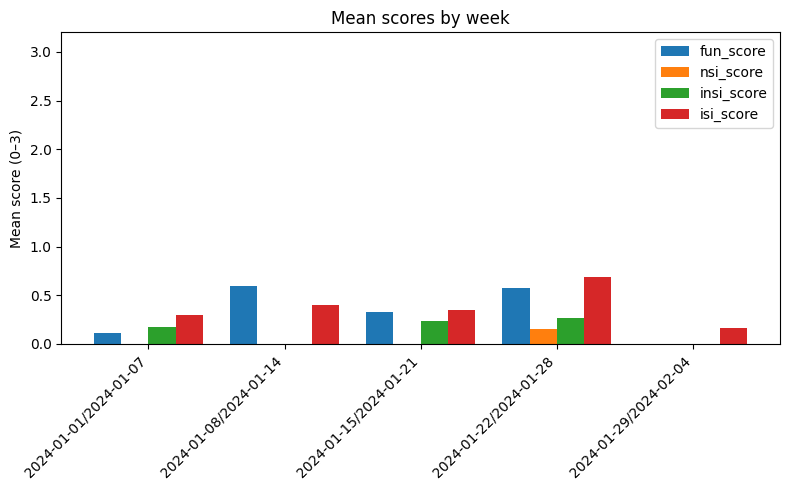

,actor_bucket,fun_score,nsi_score,insi_score,isi_score,n
5,Other,0.428571,0.000000,0.214286,0.547619,42
9,UlisesGascon,0.111111,0.166667,0.111111,0.166667,18
11,dougwilson,0.166667,0.500000,0.500000,0.500000,6


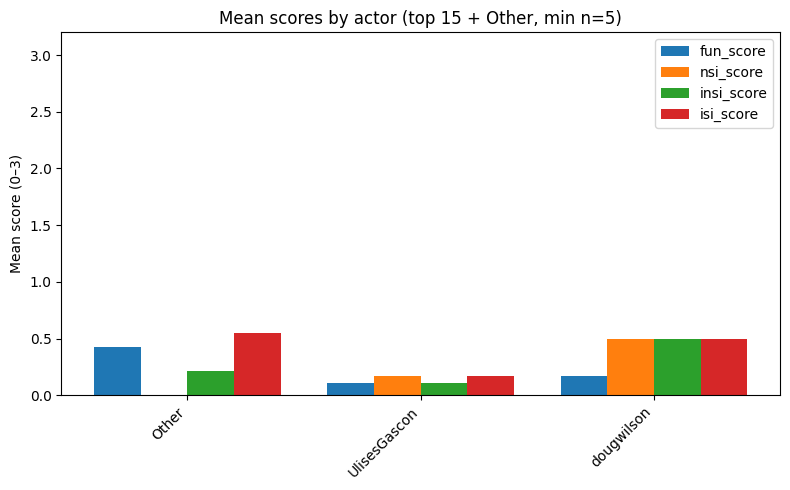

In [24]:
if len(df):
    for col in ["event_type", "repo", "author_association"]:
        summ = summarize_by(df, col)
        print(col, "— groups:", len(summ))
        display(summ.head(20))
        plot_group_means(summ.sort_values(col), col, f"Mean scores by {col}")

    by_week = df.copy()
    by_week["event_week"] = by_week["event_date"].dt.to_period("W").astype(str)
    summ_w = summarize_by(by_week, "event_week")
    display(summ_w.head(20))
    plot_group_means(summ_w.sort_values("event_week"), "event_week", "Mean scores by week")

    df_actor = df.copy()
    df_actor["actor_bucket"] = bucket_top_n_series(df_actor["actor_login"], ACTOR_TOP_N)
    summ_a = summarize_by(df_actor, "actor_bucket", min_n=ACTOR_MIN_N)
    display(summ_a.head(25))
    plot_group_means(summ_a.sort_values("n", ascending=False), "actor_bucket", f"Mean scores by actor (top {ACTOR_TOP_N} + Other, min n={ACTOR_MIN_N})")

### Two-way groupings (heatmap)

Example: repo × event_type for **NSI**; change `value` to `insi_score`, `isi_score`, or `fun_score` as needed.

,repo,event_type,fun_score,nsi_score,insi_score,isi_score,n
1,expressjs/express,PullRequestEvent,0.103448,0.000000,0.137931,0.034483,58
0,expressjs/express,IssueCommentEvent,0.789474,0.157895,0.342105,1.078947,38


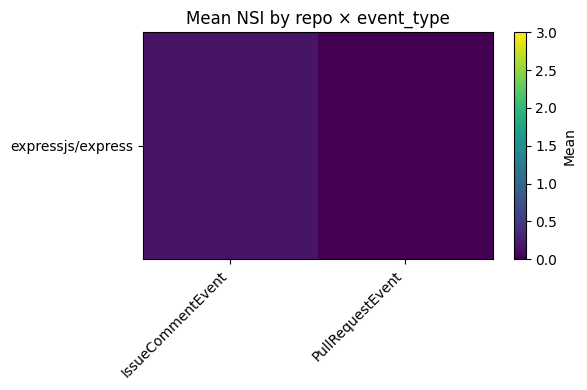

,repo,author_association,fun_score,nsi_score,insi_score,isi_score,n
1,expressjs/express,NONE,0.380435,0.00,0.184783,0.434783,92
0,expressjs/express,MEMBER,0.375000,0.75,0.500000,0.750000,8


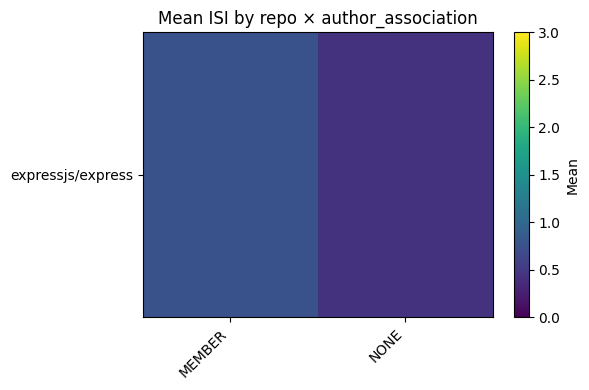

In [25]:
if len(df):
    g_rt = ["repo", "event_type"]
    means_rt = df.groupby(g_rt, dropna=False)[SCORE_COLS].mean().reset_index()
    counts_rt = df.groupby(g_rt, dropna=False).size().reset_index(name="n")
    tw = means_rt.merge(counts_rt, on=g_rt)
    tw = tw[tw["n"] >= ACTOR_MIN_N]
    display(tw.sort_values("n", ascending=False).head(30))
    plot_heatmap(tw, row="repo", col="event_type", value="nsi_score", title="Mean NSI by repo × event_type")

    g_ra = ["repo", "author_association"]
    means_ra = df.groupby(g_ra, dropna=False)[SCORE_COLS].mean().reset_index()
    counts_ra = df.groupby(g_ra, dropna=False).size().reset_index(name="n")
    tw2 = means_ra.merge(counts_ra, on=g_ra)
    tw2 = tw2[tw2["n"] >= ACTOR_MIN_N]
    display(tw2.sort_values("n", ascending=False).head(30))
    plot_heatmap(
        tw2,
        row="repo",
        col="author_association",
        value="isi_score",
        title="Mean ISI by repo × author_association",
    )